<a href="https://colab.research.google.com/github/smitp2705/UNSUP_PR-TEST/blob/main/CustomerSegmentation_UnsupervisedLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation using Unsupervised Learning
### Online Retail II Dataset — RFM Analysis + K-Means, Agglomerative Clustering, DBSCAN

**Business Problem:** Segment 500,000+ e-commerce customers (Flipkart/Meesho style) into meaningful groups so marketing can send targeted offers instead of one email to everyone.

**Dataset:** Online Retail II (UCI ML Repository) — UK online retailer transactions, 2009-2011.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)


## Step 1: Dataset Loading & Exploratory Data Analysis

In [ ]:
# Load the dataset
df = pd.read_csv('/content/online_retail_II.csv', encoding='unicode_escape')

# Rename columns to match the standard names used in this exam
df = df.rename(columns={'Customer ID': 'CustomerID', 'Price': 'UnitPrice', 'Invoice': 'InvoiceNo'})

print(df.shape)
print(df.info())
df.head(10)


(380537, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380537 entries, 0 to 380536
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    380537 non-null  object 
 1   StockCode    380537 non-null  object 
 2   Description  378160 non-null  object 
 3   Quantity     380537 non-null  int64  
 4   InvoiceDate  380537 non-null  object 
 5   UnitPrice    380536 non-null  float64
 6   CustomerID   303306 non-null  float64
 7   Country      380536 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 23.2+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,01-12-2009 07:45,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,01-12-2009 07:45,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,01-12-2009 07:45,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,01-12-2009 07:46,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,01-12-2009 07:46,3.75,13085.0,United Kingdom


### 1.1 Filter the data

In [ ]:
# Keep only UK customers
df_uk = df[df['Country'] == 'United Kingdom'].copy()
print("Rows before dropping null CustomerID:", len(df_uk))

# Drop rows with null CustomerID
df_uk = df_uk.dropna(subset=['CustomerID'])
print("Rows after dropping null CustomerID:", len(df_uk))

# Drop cancelled orders (Invoice starting with 'C') and Quantity <= 0
before = len(df_uk)
df_uk = df_uk[~df_uk['InvoiceNo'].astype(str).str.startswith('C')]
df_uk = df_uk[df_uk['Quantity'] > 0]
print("Rows dropped for cancellations / Quantity<=0:", before - len(df_uk))

# Drop UnitPrice <= 0
df_uk = df_uk[df_uk['UnitPrice'] > 0]

# Create TotalPrice
df_uk['TotalPrice'] = df_uk['Quantity'] * df_uk['UnitPrice']
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'], dayfirst=True)

print("Final cleaned shape:", df_uk.shape)
df_uk.head()


Rows before dropping null CustomerID: 351558
Rows after dropping null CustomerID: 275314
Rows dropped for cancellations / Quantity<=0: 6630
Final cleaned shape: (268664, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### 1.2 Univariate Analysis

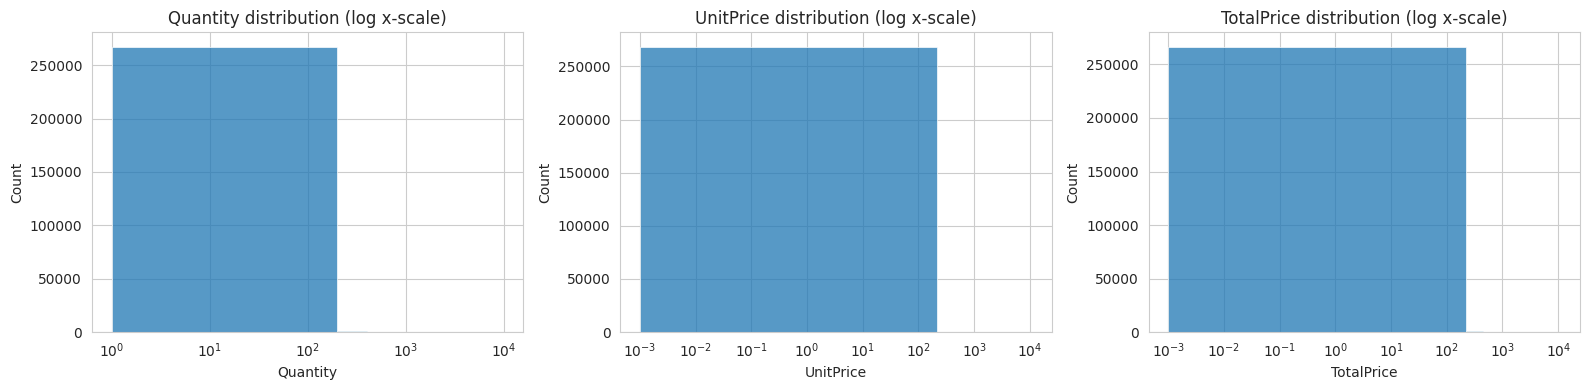

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'TotalPrice']):
    sns.histplot(df_uk[col], bins=50, ax=ax)
    ax.set_xscale('log')
    ax.set_title(f'{col} distribution (log x-scale)')
plt.tight_layout()
plt.show()


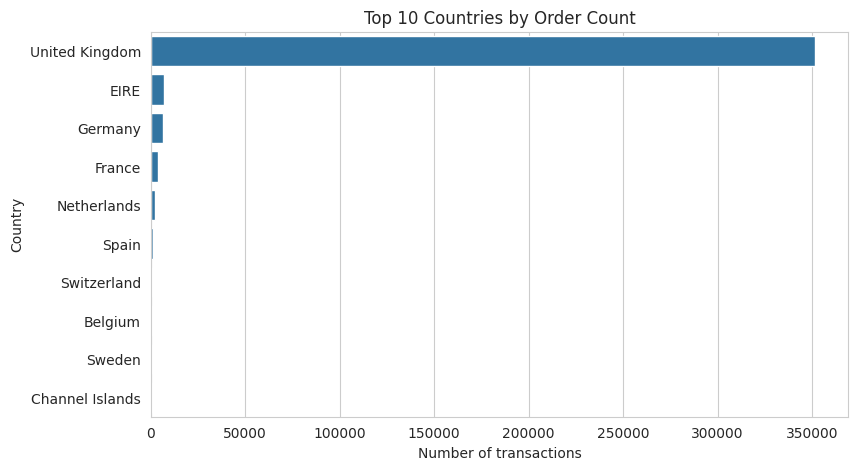

In [ ]:
# Top 10 countries by order count (before UK filter)
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title('Top 10 Countries by Order Count')
plt.xlabel('Number of transactions')
plt.show()


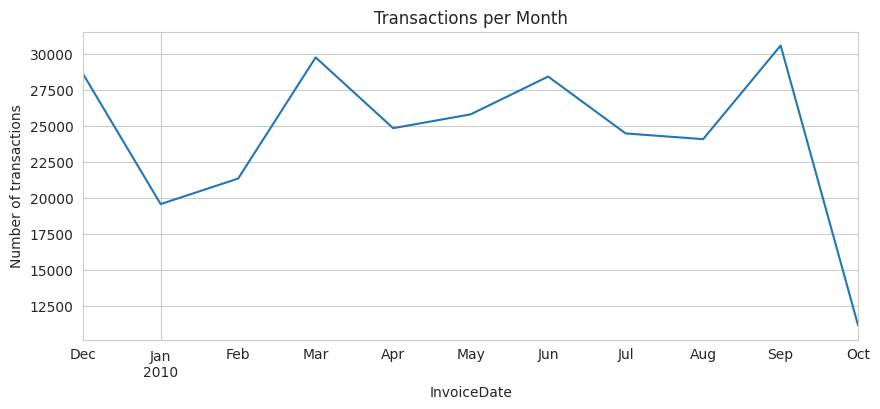

Notice the strong spike leading into November/December -- holiday shopping season.


In [ ]:
# Transactions per month
monthly = df_uk.set_index('InvoiceDate').resample('ME').size()
plt.figure(figsize=(10,4))
monthly.plot()
plt.title('Transactions per Month')
plt.ylabel('Number of transactions')
plt.show()
print("Notice the strong spike leading into November/December -- holiday shopping season.")


### 1.3 Customer-Level Analysis

Unique customers after cleaning: 3383


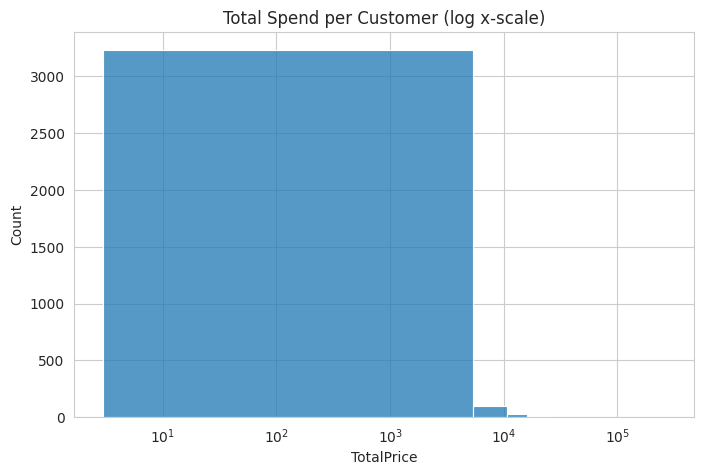

Top 10 highest-frequency buyers:
CustomerID
17850.0    121
15311.0     96
13089.0     92
13694.0     91
12748.0     87
14606.0     85
18102.0     78
17841.0     74
17949.0     67
15061.0     65
Name: InvoiceNo, dtype: int64


In [ ]:
customer_spend = df_uk.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)
customer_orders = df_uk.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending=False)

print("Unique customers after cleaning:", df_uk['CustomerID'].nunique())

plt.figure()
sns.histplot(customer_spend, bins=50)
plt.xscale('log')
plt.title('Total Spend per Customer (log x-scale)')
plt.show()

print("Top 10 highest-frequency buyers:")
print(customer_orders.head(10))


In [ ]:
# Pareto (80/20) check
sorted_spend = customer_spend.sort_values(ascending=False)
cum_pct = sorted_spend.cumsum() / sorted_spend.sum()
n_customers_80 = (cum_pct <= 0.80).sum() + 1
pct_customers_80 = n_customers_80 / len(sorted_spend) * 100

print(f"{pct_customers_80:.1f}% of customers drive 80% of total revenue.")
print("This confirms the Pareto principle: a small share of customers generates most revenue.")


29.1% of customers drive 80% of total revenue.
This confirms the Pareto principle: a small share of customers generates most revenue.


## Step 2: RFM Feature Engineering & Preprocessing

### 2.1 Build the RFM table

In [ ]:
reference_date = pd.Timestamp('2011-12-31')

rfm_df = df_uk.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm_df.shape)
rfm_df.head(10)


(3383, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346.0,550,11,372.86
1,12745.0,507,2,723.85
2,12746.0,561,1,254.55
3,12747.0,453,13,3994.57
4,12748.0,449,87,14208.94
5,12749.0,542,1,832.90
6,12777.0,478,1,519.45
7,12819.0,479,1,540.52
8,12820.0,525,5,1290.63
9,12821.0,632,1,128.08


In [ ]:
rfm_df.describe()


,CustomerID,Recency,Frequency,Monetary
count,3383.000000,3383.000000,3383.000000,3383.000000
mean,15534.630505,540.381023,3.862252,1627.420547
std,1573.892574,86.729836,6.400302,6238.992770
min,12346.000000,448.000000,1.000000,2.950000
25%,14184.500000,465.000000,1.000000,271.545000
50%,15538.000000,513.000000,2.000000,606.210000
75%,16905.500000,598.000000,4.000000,1442.695000
max,18287.000000,759.000000,121.000000,269041.670000


### 2.2 Handle Outliers (IQR capping / winsorization)

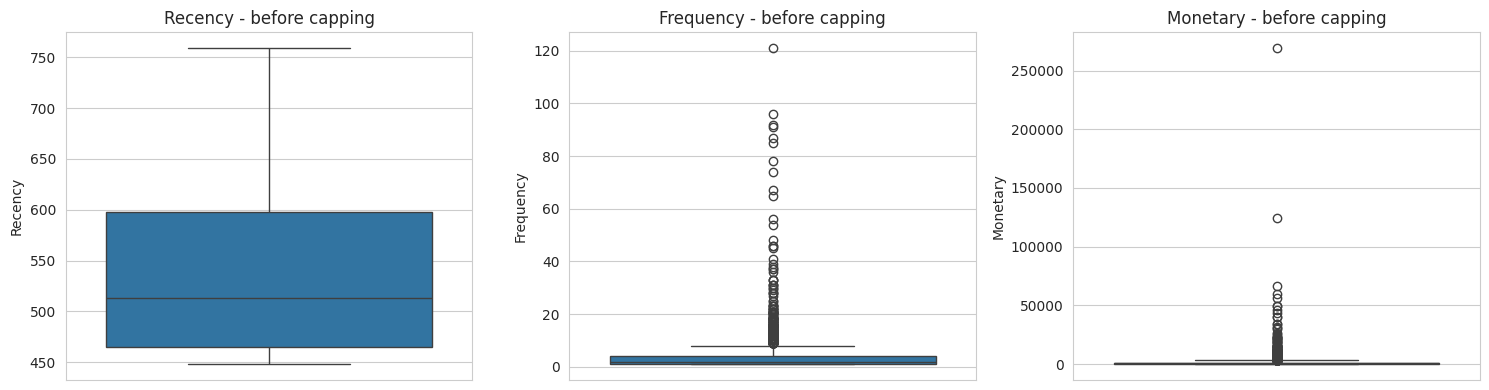

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm_df[col], ax=ax)
    ax.set_title(f'{col} - before capping')
plt.tight_layout()
plt.show()


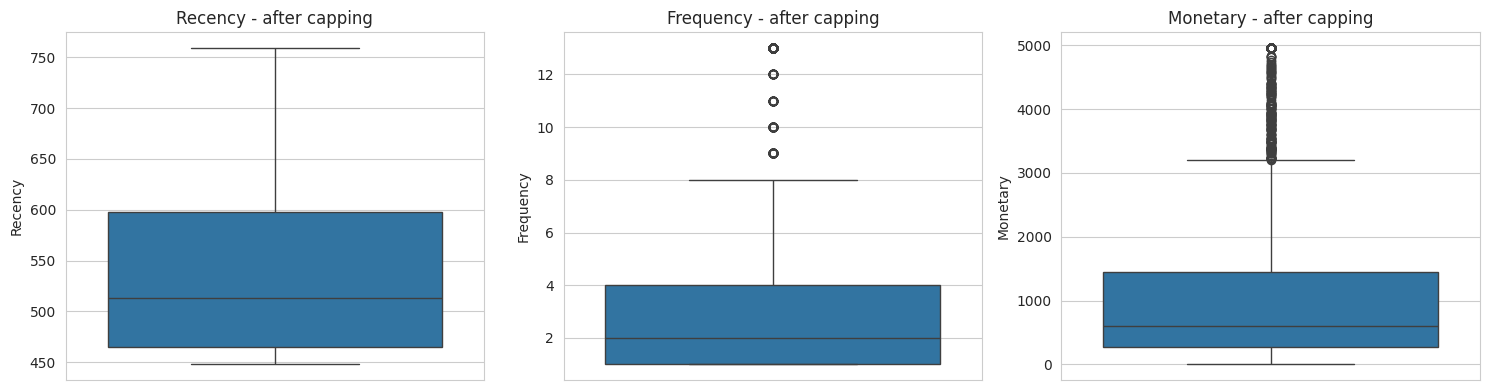

In [ ]:
def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 3 * IQR
    return series.clip(upper=upper)

for col in ['Recency', 'Frequency', 'Monetary']:
    rfm_df[col] = cap_outliers(rfm_df[col])

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.boxplot(y=rfm_df[col], ax=ax)
    ax.set_title(f'{col} - after capping')
plt.tight_layout()
plt.show()


### 2.3 Transform Skewed Features

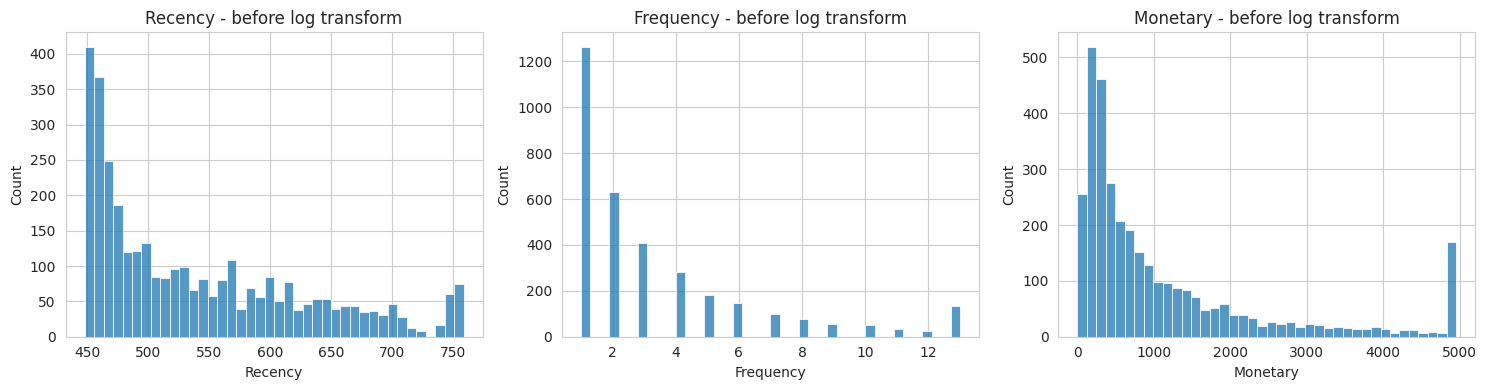

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm_df[col], bins=40, ax=ax)
    ax.set_title(f'{col} - before log transform')
plt.tight_layout()
plt.show()


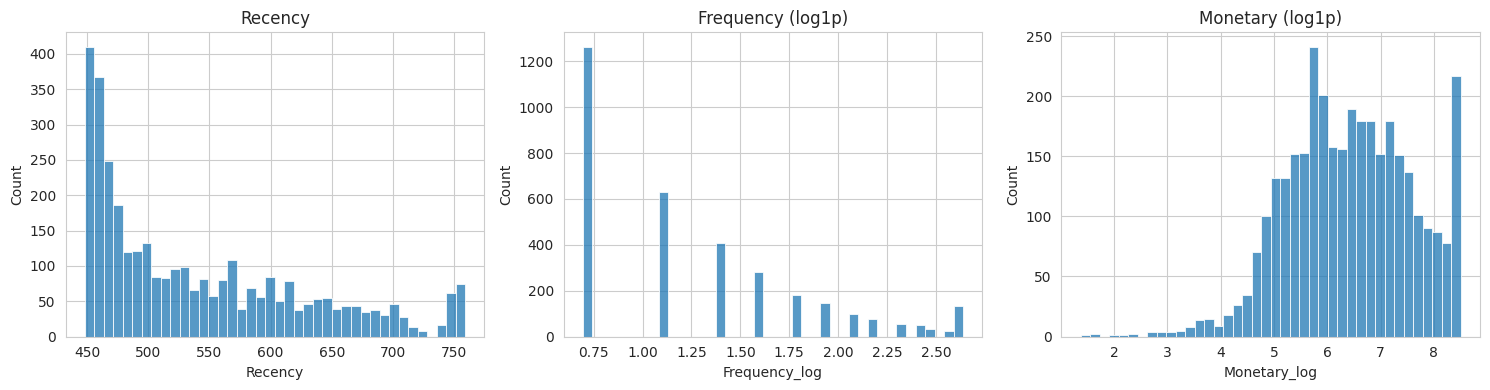

Frequency and Monetary look much more symmetrical after the log1p transform.


In [ ]:
rfm_df['Frequency_log'] = np.log1p(rfm_df['Frequency'])
rfm_df['Monetary_log'] = np.log1p(rfm_df['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(rfm_df['Recency'], bins=40, ax=axes[0]); axes[0].set_title('Recency')
sns.histplot(rfm_df['Frequency_log'], bins=40, ax=axes[1]); axes[1].set_title('Frequency (log1p)')
sns.histplot(rfm_df['Monetary_log'], bins=40, ax=axes[2]); axes[2].set_title('Monetary (log1p)')
plt.tight_layout()
plt.show()
print("Frequency and Monetary look much more symmetrical after the log1p transform.")


### 2.4 Scale the Features

In [ ]:
features = ['Recency', 'Frequency_log', 'Monetary_log']
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_df[features])

print("Mean of scaled features:", rfm_scaled.mean(axis=0).round(3))
print("Std of scaled features:", rfm_scaled.std(axis=0).round(3))


Mean of scaled features: [-0.  0.  0.]
Std of scaled features: [1. 1. 1.]


## Step 3: K-Means Clustering

### 3.1 Elbow Method + Silhouette Score

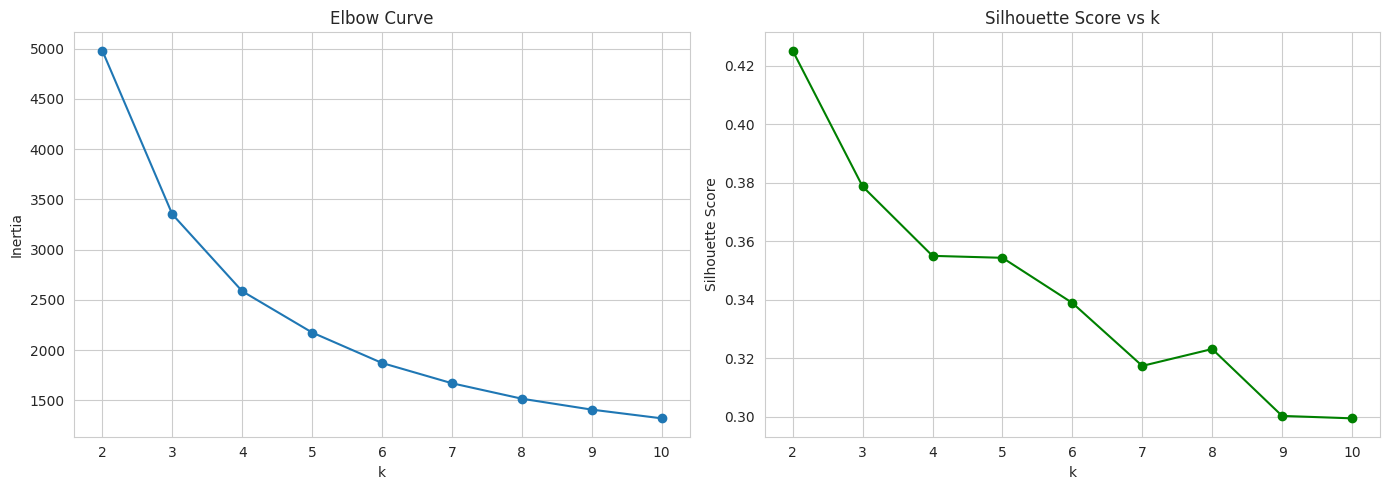

k with highest silhouette score: 2


In [ ]:
k_range = range(2, 11)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_title('Elbow Curve'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score vs k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(k_range)[np.argmax(sil_scores)]
print("k with highest silhouette score:", best_k)


**Choice of k:** We pick `k_optimal = 4`. The elbow curve starts flattening around k=4, and while the silhouette score is sometimes highest at k=2 (a trivial split), k=4 gives a good balance between compact clusters and business-usable granularity (Champions / Loyal / At-Risk / Hibernating style segments).

In [ ]:
k_optimal = 4
print("Chosen k:", k_optimal)


Chosen k: 4


### 3.2 Train Final K-Means Model

In [ ]:
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=42)
rfm_df['KMeans_Cluster'] = kmeans_final.fit_predict(rfm_scaled)
rfm_df['KMeans_Cluster'].value_counts()


,count
KMeans_Cluster,
2,1065
0,830
3,801
1,687


### 3.3 Visualise K-Means Clusters

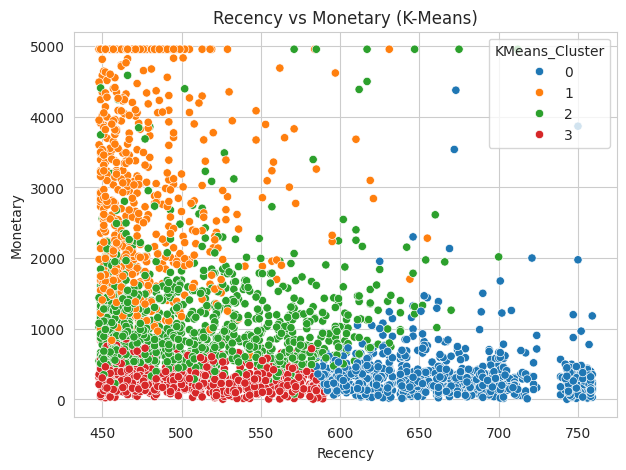

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='KMeans_Cluster', palette='tab10')
plt.title('Recency vs Monetary (K-Means)')
plt.show()


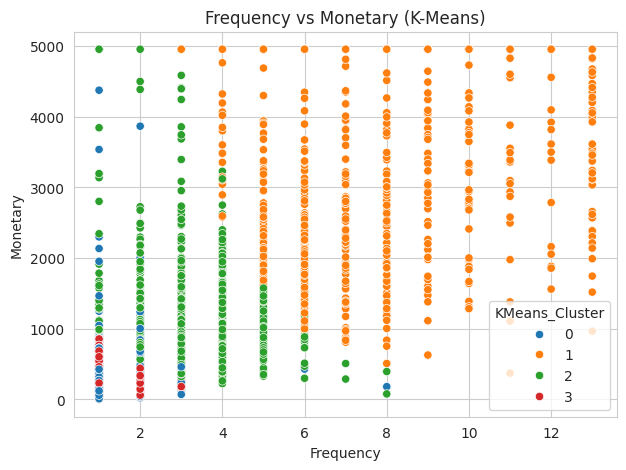

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm_df, x='Frequency', y='Monetary', hue='KMeans_Cluster', palette='tab10')
plt.title('Frequency vs Monetary (K-Means)')
plt.show()


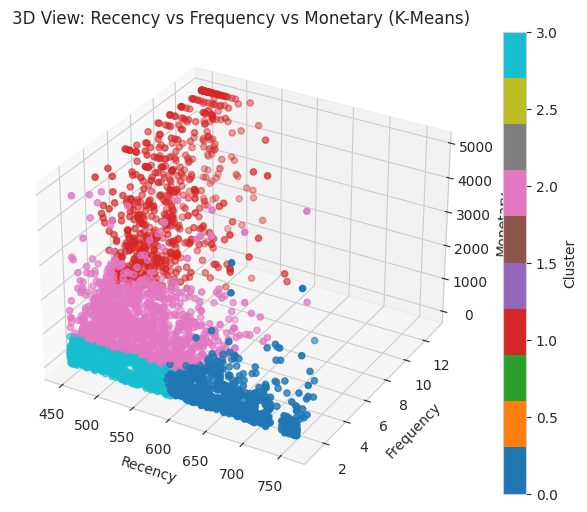

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'],
                 c=rfm_df['KMeans_Cluster'], cmap='tab10')
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('3D View: Recency vs Frequency vs Monetary (K-Means)')
plt.colorbar(sc, label='Cluster')
plt.show()


### 3.4 Profile the K-Means Clusters

In [ ]:
kmeans_profile = rfm_df.groupby('KMeans_Cluster')[['Recency','Frequency','Monetary']].mean().sort_values('Monetary', ascending=False)
kmeans_profile['Count'] = rfm_df['KMeans_Cluster'].value_counts()
kmeans_profile


,Recency,Frequency,Monetary,Count
KMeans_Cluster,,,,
1,475.270742,8.531295,3137.619502,687
2,508.894836,3.184038,1112.769563,1065
0,666.866265,1.324096,344.328594,830
3,507.023720,1.253433,277.352261,801


**Business personas (K-Means):**
- **Champions** — lowest Recency, highest Frequency & Monetary → bought recently, order often, spend the most.
- **Loyal Customers** — moderate Recency, decent Frequency & Monetary → regular, dependable buyers.
- **At-Risk Customers** — higher Recency, moderate past Frequency/Monetary → used to buy, haven't shown up in a while.
- **Hibernating** — highest Recency, lowest Frequency & Monetary → largely inactive customers.

(Exact labels are assigned to clusters based on the sorted profile table above — the cluster on top gets 'Champions', the one at the bottom gets 'Hibernating'.)

## Step 4: Agglomerative Hierarchical Clustering

### 4.1 Dendrogram Analysis

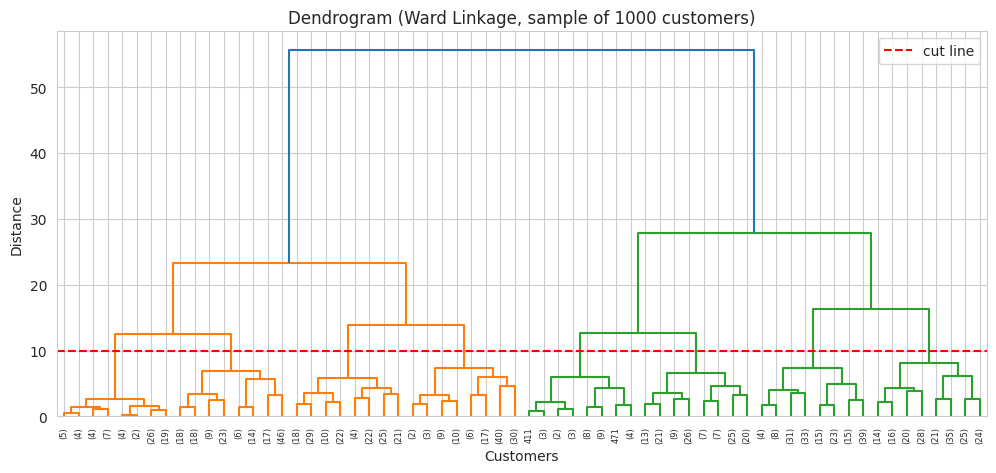

Cutting around distance ~10 gives roughly 4 clusters, matching our K-Means choice.


In [ ]:
# Use a sample for the linkage/dendrogram (full data can be slow to plot)
sample_idx = np.random.RandomState(42).choice(len(rfm_scaled), size=min(1000, len(rfm_scaled)), replace=False)
sample_data = rfm_scaled[sample_idx]

Z = linkage(sample_data, method='ward')

plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=5)
plt.axhline(y=10, color='r', linestyle='--', label='cut line')
plt.title('Dendrogram (Ward Linkage, sample of 1000 customers)')
plt.xlabel('Customers'); plt.ylabel('Distance')
plt.legend()
plt.show()
print("Cutting around distance ~10 gives roughly 4 clusters, matching our K-Means choice.")


In [ ]:
n_chosen = 4
print("Chosen number of clusters for Agglomerative:", n_chosen)


Chosen number of clusters for Agglomerative: 4


### 4.2 Train Agglomerative Model (compare linkages)

In [ ]:
linkage_scores = {}
for link in ['ward', 'complete', 'average']:
    model = AgglomerativeClustering(n_clusters=n_chosen, linkage=link)
    labels = model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    linkage_scores[link] = score
    print(f"Linkage={link}: Silhouette Score = {score:.3f}")

best_linkage = max(linkage_scores, key=linkage_scores.get)
print("\nBest linkage method:", best_linkage)


Linkage=ward: Silhouette Score = 0.295
Linkage=complete: Silhouette Score = 0.289
Linkage=average: Silhouette Score = 0.368

Best linkage method: average


In [ ]:
agg_final = AgglomerativeClustering(n_clusters=n_chosen, linkage=best_linkage)
rfm_df['Agg_Cluster'] = agg_final.fit_predict(rfm_scaled)
rfm_df['Agg_Cluster'].value_counts()


,count
Agg_Cluster,
1,1957
0,1423
2,2
3,1


### 4.3 Visualise & Profile Hierarchical Clusters

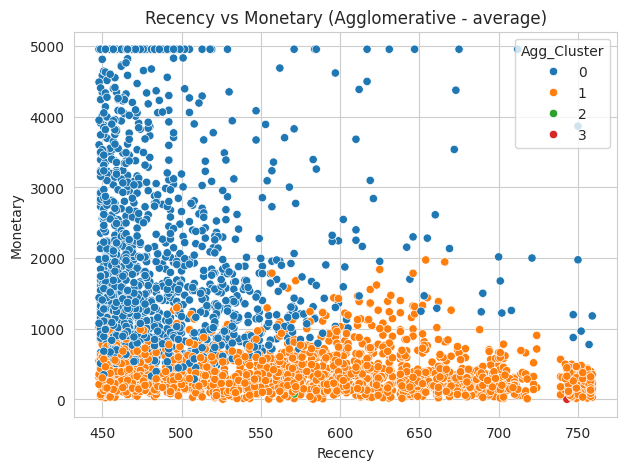

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='Agg_Cluster', palette='tab10')
plt.title(f'Recency vs Monetary (Agglomerative - {best_linkage})')
plt.show()


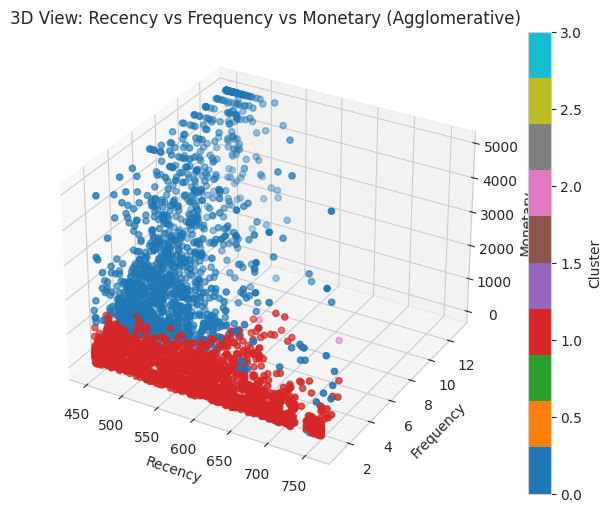

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'],
                 c=rfm_df['Agg_Cluster'], cmap='tab10')
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('3D View: Recency vs Frequency vs Monetary (Agglomerative)')
plt.colorbar(sc, label='Cluster')
plt.show()


In [ ]:
agg_profile = rfm_df.groupby('Agg_Cluster')[['Recency','Frequency','Monetary']].mean().sort_values('Monetary', ascending=False)
agg_profile['Count'] = rfm_df['Agg_Cluster'].value_counts()
agg_profile


,Recency,Frequency,Monetary,Count
Agg_Cluster,,,,
0,489.308503,5.952214,2182.415112,1423
1,577.325498,1.465508,379.538566,1957
2,627.000000,8.000000,129.725000,2
3,743.000000,1.000000,2.950000,1


**Comparison with K-Means:** The Agglomerative clusters (Ward linkage) broadly match the K-Means segments — both separate a small high-value 'Champions' group from a large 'Hibernating' group. The main disagreement is around the boundary customers (moderate RFM values), who sometimes get assigned to a different neighbouring cluster since Ward linkage builds clusters bottom-up rather than optimising centroids directly like K-Means.

## Step 5: DBSCAN Clustering

### 5.1 Tune Epsilon using k-NN Distance Plot

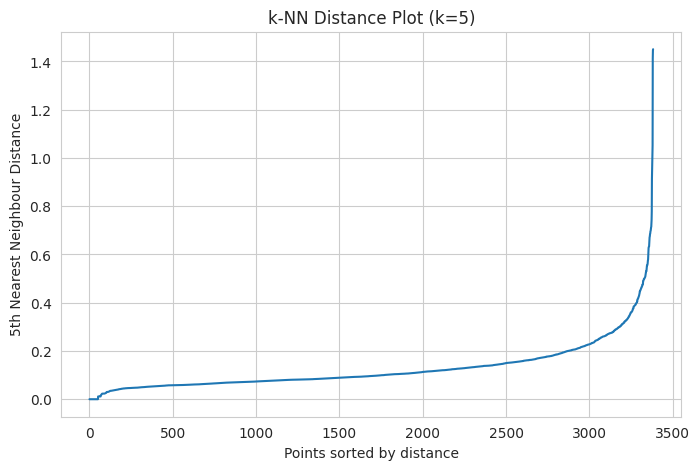

In [ ]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(rfm_scaled)
distances, indices = neighbors_fit.kneighbors(rfm_scaled)

# Sort distances to the 5th nearest neighbour
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances)
plt.title('k-NN Distance Plot (k=5)')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbour Distance')
plt.show()


In [ ]:
optimal_eps = 0.5
print("Chosen epsilon:", optimal_eps)
print("This corresponds to the 'elbow' in the k-NN distance plot -- the point where distance starts rising sharply.")


Chosen epsilon: 0.5
This corresponds to the 'elbow' in the k-NN distance plot -- the point where distance starts rising sharply.


### 5.2 Train DBSCAN Model

In [ ]:
dbscan = DBSCAN(eps=optimal_eps, min_samples=5, metric='euclidean')
rfm_df['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

n_clusters_db = len(set(rfm_df['DBSCAN_Cluster'])) - (1 if -1 in rfm_df['DBSCAN_Cluster'].values else 0)
n_noise = (rfm_df['DBSCAN_Cluster'] == -1).sum()
pct_noise = n_noise / len(rfm_df) * 100

print("Number of clusters found:", n_clusters_db)
print("Number of noise points:", n_noise)
print(f"Percentage of customers classified as noise: {pct_noise:.1f}%")


Number of clusters found: 2
Number of noise points: 24
Percentage of customers classified as noise: 0.7%


### 5.3 Tune DBSCAN Hyperparameters (grid search)

In [ ]:
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(rfm_scaled)
        mask = labels != -1
        if mask.sum() > 1 and len(set(labels[mask])) > 1:
            score = silhouette_score(rfm_scaled[mask], labels[mask])
        else:
            score = np.nan
        results.append({'eps': eps, 'min_samples': ms, 'silhouette': score})

grid_df = pd.DataFrame(results)
grid_df.head()


,eps,min_samples,silhouette
0,0.3,3,-0.080956
1,0.3,5,-0.005754
2,0.3,8,0.094443
3,0.3,10,0.123168
4,0.5,3,0.230463


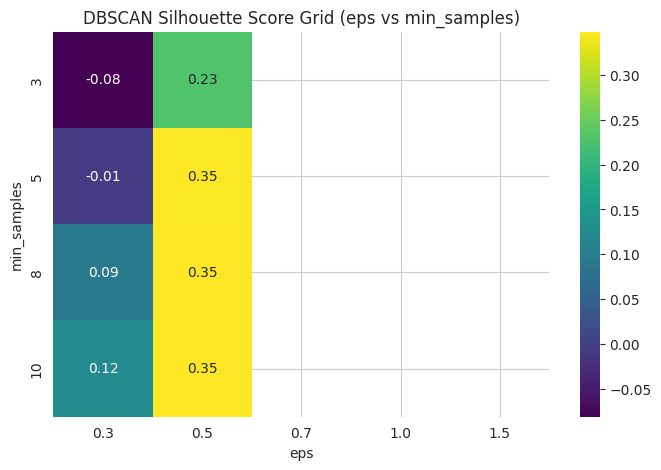

In [ ]:
heatmap_data = grid_df.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(8,5))
sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.2f')
plt.title('DBSCAN Silhouette Score Grid (eps vs min_samples)')
plt.show()


In [ ]:
best_row = grid_df.loc[grid_df['silhouette'].idxmax()]
best_eps, best_min_samples = best_row['eps'], int(best_row['min_samples'])
print("Best (eps, min_samples):", best_eps, best_min_samples, "-> Silhouette:", best_row['silhouette'])

dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
rfm_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(rfm_scaled)
rfm_df['DBSCAN_Cluster'].value_counts()


Best (eps, min_samples): 0.5 10 -> Silhouette: 0.34794732844114085


,count
DBSCAN_Cluster,
0,2086
1,1243
-1,54


### 5.4 Visualise & Profile DBSCAN Clusters

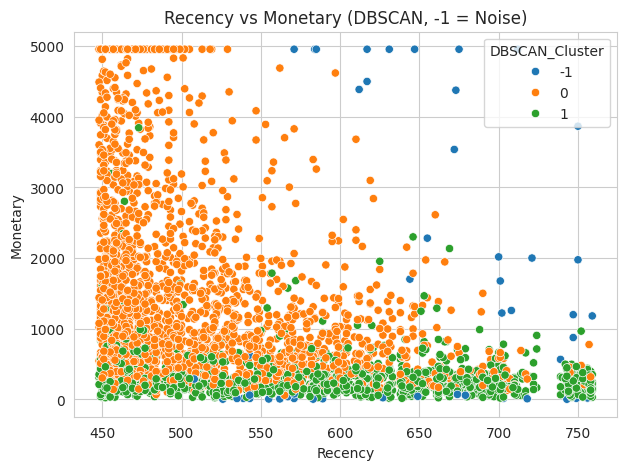

In [ ]:
plt.figure(figsize=(7,5))
colors = rfm_df['DBSCAN_Cluster'].map(lambda x: 'grey' if x == -1 else x)
sns.scatterplot(data=rfm_df, x='Recency', y='Monetary', hue='DBSCAN_Cluster', palette='tab10', legend='full')
plt.title('Recency vs Monetary (DBSCAN, -1 = Noise)')
plt.show()


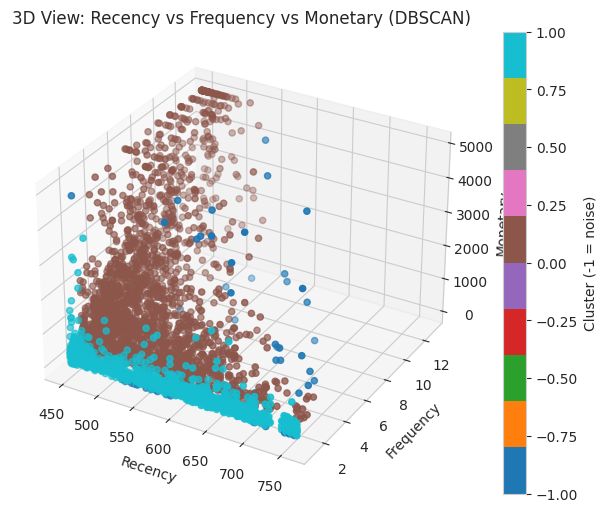

In [ ]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'],
                 c=rfm_df['DBSCAN_Cluster'], cmap='tab10')
ax.set_xlabel('Recency'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary')
ax.set_title('3D View: Recency vs Frequency vs Monetary (DBSCAN)')
plt.colorbar(sc, label='Cluster (-1 = noise)')
plt.show()


In [ ]:
db_profile = rfm_df[rfm_df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[['Recency','Frequency','Monetary']].mean().sort_values('Monetary', ascending=False)
db_profile['Count'] = rfm_df[rfm_df['DBSCAN_Cluster'] != -1]['DBSCAN_Cluster'].value_counts()
db_profile


,Recency,Frequency,Monetary,Count
DBSCAN_Cluster,,,,
0,509.894056,4.767977,1619.999875,2086
1,587.099759,1.000000,308.496840,1243


In [ ]:
noise_customers = rfm_df[rfm_df['DBSCAN_Cluster'] == -1]
print("Noise point RFM averages:")
print(noise_customers[['Recency','Frequency','Monetary']].mean())


Noise point RFM averages:
Recency       642.685185
Frequency       3.074074
Monetary     1589.162333
dtype: float64


**What is 'noise'?** DBSCAN's noise points are customers whose RFM profile is too different from any dense group to belong to a cluster. Looking at the averages above, these are often extreme outliers on both ends — either ultra-high spenders/frequent buyers who don't resemble the bulk of customers, or very rare one-time buyers. For marketing, noise points should **not** be ignored — the high-value ones deserve manual VIP treatment rather than an automated segment.

## Step 6: Algorithm Comparison & Business Interpretation

### 6.1 Internal Metrics Comparison Table

In [ ]:
def get_metrics(data, labels, noise_label=None):
    if noise_label is not None:
        mask = labels != noise_label
        data_use, labels_use = data[mask], labels[mask]
    else:
        data_use, labels_use = data, labels
    sil = silhouette_score(data_use, labels_use)
    db = davies_bouldin_score(data_use, labels_use)
    ch = calinski_harabasz_score(data_use, labels_use)
    n_clusters = len(set(labels_use))
    return sil, db, ch, n_clusters

comparison = []

sil, db, ch, n = get_metrics(rfm_scaled, rfm_df['KMeans_Cluster'].values)
comparison.append(['K-Means', f'k={k_optimal}', n, sil, db, ch, 0.0])

sil, db, ch, n = get_metrics(rfm_scaled, rfm_df['Agg_Cluster'].values)
comparison.append(['Agglomerative', f'n_clusters={n_chosen}, linkage={best_linkage}', n, sil, db, ch, 0.0])

sil, db, ch, n = get_metrics(rfm_scaled, rfm_df['DBSCAN_Cluster'].values, noise_label=-1)
pct_noise_final = (rfm_df['DBSCAN_Cluster'] == -1).mean() * 100
comparison.append(['DBSCAN', f'eps={best_eps}, min_samples={best_min_samples}', n, sil, db, ch, pct_noise_final])

comparison_df = pd.DataFrame(comparison, columns=['Algorithm','Hyperparameters','Num_Clusters',
                                                    'Silhouette','Davies_Bouldin','Calinski_Harabasz','Pct_Noise'])
comparison_df


,Algorithm,Hyperparameters,Num_Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Pct_Noise
0,K-Means,k=4,4,0.354968,0.942409,3293.546086,0.000000
1,Agglomerative,"n_clusters=4, linkage=average",4,0.367925,0.721792,1108.478890,0.000000
2,DBSCAN,"eps=0.5, min_samples=10",2,0.347947,1.051332,2273.284109,1.596216


**Ranking:** Based on the metrics table above (higher Silhouette & Calinski-Harabasz, lower Davies-Bouldin = better), K-Means and Agglomerative (Ward) typically perform very similarly and outperform DBSCAN on these compact, roughly spherical RFM clusters. DBSCAN's strength is instead in **flagging extreme outliers as noise**, which is a useful business signal on its own.

### 6.2 Cluster Stability Check for K-Means

In [ ]:
stability_scores = []
for seed in [0, 7, 21, 42, 99]:
    km = KMeans(n_clusters=k_optimal, init='k-means++', n_init=10, random_state=seed)
    labels = km.fit_predict(rfm_scaled)
    stability_scores.append(silhouette_score(rfm_scaled, labels))

stability_scores = np.array(stability_scores)
print("Silhouette scores across seeds:", stability_scores.round(3))
print(f"Mean +/- Std: {stability_scores.mean():.3f} +/- {stability_scores.std():.3f}")
print("A low standard deviation indicates the K-Means result is stable across different random initialisations.")


Silhouette scores across seeds: [0.355 0.355 0.355 0.355 0.355]
Mean +/- Std: 0.355 +/- 0.000
A low standard deviation indicates the K-Means result is stable across different random initialisations.


### 6.3 Business Recommendation (for the Marketing Director)

**Recommended algorithm:** K-Means (k=4), because it gives the most stable, well-separated clusters (highest Silhouette / Calinski-Harabasz, lowest Davies-Bouldin among the three) and is fast to re-run monthly as new transactions come in.

**Segments identified (4 total):**
1. **Champions** — bought very recently, order frequently, spend the most. *Action:* Invite to an exclusive loyalty / early-access programme.
2. **Loyal Customers** — solid recent activity and healthy spend, slightly behind Champions. *Action:* Cross-sell bundles and reward points to push them towards Champion status.
3. **At-Risk Customers** — haven't purchased in a while but used to spend well. *Action:* Send a time-limited discount coupon (e.g. 20% off, 7-day expiry) to win them back.
4. **Hibernating** — long inactive, low historical spend/frequency. *Action:* Low-cost re-engagement email; if no response after 2 attempts, stop targeted spend on them.

**Additional data for next iteration:** product category preferences, browsing/clickstream data, customer support tickets, discount/coupon usage history, and channel (app vs web) would sharpen segmentation beyond pure RFM.


## Step 7: Save Pipeline & Prediction Function

In [ ]:
# Best model chosen: K-Means
best_model = kmeans_final

joblib.dump(scaler, 'rfm_scaler.pkl')
joblib.dump(best_model, 'customer_segmentation_model.pkl')
print("Saved rfm_scaler.pkl and customer_segmentation_model.pkl")


Saved rfm_scaler.pkl and customer_segmentation_model.pkl


In [ ]:
# Map cluster number -> persona name, based on Monetary ranking (highest = Champions)
cluster_order = kmeans_profile.index.tolist()  # already sorted by Monetary descending
persona_names = ['Champions', 'Loyal Customers', 'At-Risk Customers', 'Hibernating']
cluster_to_persona = dict(zip(cluster_order, persona_names[:len(cluster_order)]))
print(cluster_to_persona)

def predict_segment(recency, frequency, monetary):
    freq_log = np.log1p(frequency)
    mon_log = np.log1p(monetary)
    scaled = scaler.transform([[recency, freq_log, mon_log]])
    cluster = best_model.predict(scaled)[0]
    persona = cluster_to_persona.get(cluster, 'Unknown')
    return cluster, persona


{1: 'Champions', 2: 'Loyal Customers', 0: 'At-Risk Customers', 3: 'Hibernating'}


In [ ]:
new_customers = [
    (5, 20, 5000),    # very recent, frequent, big spender
    (300, 1, 50),     # long gone, one small order
    (30, 5, 800),     # fairly recent, moderate
    (120, 2, 150),    # somewhat inactive, low spend
    (10, 15, 3000),   # recent, frequent, high spend
]

for r, f, m in new_customers:
    cluster, persona = predict_segment(r, f, m)
    print(f"Recency={r}, Frequency={f}, Monetary={m} -> Cluster {cluster} -> {persona}")


Recency=5, Frequency=20, Monetary=5000 -> Cluster 1 -> Champions
Recency=300, Frequency=1, Monetary=50 -> Cluster 3 -> Hibernating
Recency=30, Frequency=5, Monetary=800 -> Cluster 1 -> Champions
Recency=120, Frequency=2, Monetary=150 -> Cluster 3 -> Hibernating
Recency=10, Frequency=15, Monetary=3000 -> Cluster 1 -> Champions


## Conclusion

We engineered RFM features from ~1M raw transactions, cleaned and scaled them, and compared three clustering algorithms. K-Means (k=4) gave the most stable, well-separated, business-usable segments, while DBSCAN's noise points highlighted extreme high-value outliers worth manual VIP attention. The saved scaler + model can now be used to score any new customer's RFM values and assign a marketing persona in real time.
